## Statistik Workflow of Moran Analysis Approach 2

In [20]:
import rasterio
import numpy as np
import pandas as pd
import libpysal
import geopandas as gpd
import matplotlib.pyplot as plt
from esda.moran import Moran_Local_BV
from rasterio.windows import Window
from sklearn.neighbors import BallTree

# Setup of connection to input paths (for each study region & surface hydrology map):
path_to_iceslabs = "C:/Masterarbeit/Daten Masterarbeit/Datasets/Ice Slab (Jullien)/IceSlabs_20022018/IceSlabs_20022018/20102018/Ice_Thickness_Greenland_Firn/Clipped SW/Firnice_Thickness_SW_15km.shp"
#path_to_iceslabs = "C:/Masterarbeit/Daten Masterarbeit/Datasets/Ice Slab (Jullien)/IceSlabs_20022018/IceSlabs_20022018/20102018/Ice_Thickness_Greenland_Firn/Clipped CW/Firnice_Thickness_CW_15km.shp"
#path_to_iceslabs = "C:/Masterarbeit/Daten Masterarbeit/Datasets/Ice Slab (Jullien)/IceSlabs_20022018/IceSlabs_20022018/20102018/Ice_Thickness_Greenland_Firn/Clipped NW/Firnice_Thickness_NW_15km.shp"
#path_to_iceslabs = "C:/Masterarbeit/Daten Masterarbeit/Datasets/Ice Slab (Jullien)/IceSlabs_20022018/IceSlabs_20022018/20102018/Ice_Thickness_Greenland_Firn/Clipped NO/Firnice_Thickness_NO_15km.shp"
#path_to_iceslabs = "C:/Masterarbeit/Daten Masterarbeit/Datasets/Ice Slab (Jullien)/IceSlabs_20022018/IceSlabs_20022018/20102018/Ice_Thickness_Greenland_Firn/Clipped NE/Firnice_Thickness_NE_15km.shp"
path_to_hydrology = "C:/Masterarbeit/Daten Masterarbeit/Datasets/Greenland/melting map/tedstone/master_hydrology_map_tedstone2022/master_map_GrIS_mean.vrt"



# Correct column name from dataset:
ICE_COL = '20m_ice_co' 

# Parameters for running window (2 km window -> 1 km radius)
RADIUS = 1000 
MIN_N = 50

In [21]:
# Preparing of data
points = gpd.read_file(path_to_iceslabs)

# Checking for column
if ICE_COL not in points.columns:
    print(f"ERROR: Column '{ICE_COL}' not found!")
    print("Found columns are:", list(points.columns))
else:
    # Ensure that projection is EPSG:3413
    if points.crs != "EPSG:3413":
        points = points.to_crs("EPSG:3413")

print("Same projection...")

Same projection...


In [22]:
# Extraction and averaging of ice thickness values in 1 km radius

coords = np.column_stack((points.geometry.x, points.geometry.y))
tree = BallTree(coords)

# Looking for all relevant neighbours
indices = tree.query_radius(coords, r=RADIUS)

def get_mean_thickness(idx_list, values):
    # At least 50 measurment points required
    if len(idx_list) >= MIN_N:
        return values.iloc[idx_list].mean()
    return np.nan

# New column with new values
points['ice_1km_mean'] = [get_mean_thickness(idx, points[ICE_COL]) for idx in indices]
ice_mean = points["ice_1km_mean"].mean()
print(round(ice_mean,3))

4.742


In [23]:
# Extraction and averaging of surface hydrology values in 1 km radius

with rasterio.open(path_to_hydrology) as src:
    res = src.res[0]
    half_win_pix = int(RADIUS / res)
        
    hydro_results = []
    for geom in points.geometry:
        row, col = src.index(geom.x, geom.y)
        window = Window(col - half_win_pix, row - half_win_pix, 
                        half_win_pix * 2, half_win_pix * 2)
            
        try:
            win_data = src.read(1, window=window)
            # np.nanmean ignores NoData-values
            hydro_results.append(np.nanmean(win_data))
        except:
            hydro_results.append(np.nan)

# New column for new values
points['hydro_1km_mean'] = hydro_results

hydro_mean = points["hydro_1km_mean"].mean()
print(round(hydro_mean,3))

55.984


In [5]:
# Validation and filtering of data
# Omission of NaN
df_valid = points.dropna(subset=['ice_1km_mean', 'hydro_1km_mean']).copy()

# Omission of 0-Values in hydrology data to ensure clean Box-Cox
df_valid = df_valid[df_valid['hydro_1km_mean'] > 0].copy()

print(f"Number of Points after NaN-filter: {len(points.dropna(subset=['ice_1km_mean', 'hydro_1km_mean']))}")
print(f"Number of Points after 0-filter:   {len(df_valid)}")

Number of Points after NaN-filter: 205273
Number of Points after 0-filter:   205273


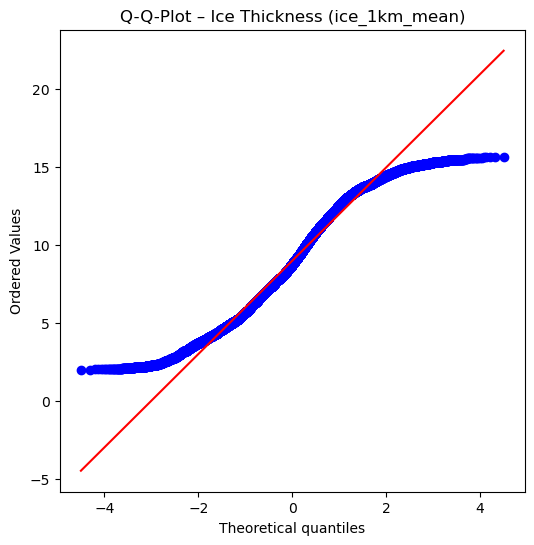

Skewness – Ice Thickness: 0.07


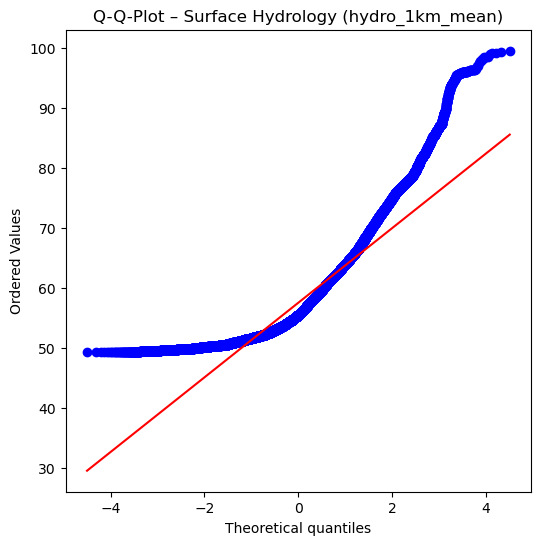

Skewness – Surface Hydrology: 1.32


In [6]:
# Distribution of 1 km mean ice thickness and 1 km mean surface hydrology data

from scipy.stats import skew
from scipy.stats import probplot
from scipy.stats import boxcox
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import scipy.stats as stats

# Q-Q Plots
# Columns
ice = df_valid["ice_1km_mean"]
hydro = df_valid["hydro_1km_mean"]

# Q-Q Plot Ice Thickness
plt.figure(figsize=(6, 6))
stats.probplot(ice, dist="norm", plot=plt)
plt.title("Q-Q-Plot – Ice Thickness (ice_1km_mean)")
plt.show()

#Skewness of Ice Thickness
ice_skew = skew(ice)
print("Skewness – Ice Thickness:", round(ice_skew, 2))

#Q-Q Plot 
plt.figure(figsize=(6, 6))
stats.probplot(hydro, dist="norm", plot=plt)
plt.title("Q-Q-Plot – Surface Hydrology (hydro_1km_mean)")
plt.show()

#Skewness of Surface Hydrology
hydro_skew = skew(hydro)
print("Skewness – Surface Hydrology:", round(hydro_skew, 2))

In [7]:
# Logarithmic transformation of ice slab values (only necessary if skewness above 1.0)
# Log-transformation
df_valid["ice_log"] = np.log(df_valid["ice_1km_mean"])

# 2. Capping at 0.99 (99. percentil)
upper_limit = df_valid["ice_log"].quantile(0.99)

# Any values above the limit will be set to the value at the limit
df_valid["ice_log_capped"] = df_valid["ice_log"].clip(upper=upper_limit)

# Calculation of skewness
log_skew_ice = skew(df_valid["ice_log"])
capped_skew_ice = skew(df_valid["ice_log_capped"])

print(f"99. percentil value: {upper_limit:.4f}")
print(f"Skewness after Log:           {log_skew_ice:.2f}")
print(f"Skewness after Log + Capping: {capped_skew_ice:.2f}")

99. percentil value: 2.6984
Skewness after Log:           -0.63
Skewness after Log + Capping: -0.63


In [8]:
# Logarithmic transformation of surface hydrology values (only necessary if skewness above 1.0)
# Log-transformation
df_valid["hydro_log"] = np.log(df_valid["hydro_1km_mean"])

# Capping at 0.99 (99. percentil)
upper_limit = df_valid["hydro_log"].quantile(0.99)

# Any values above the limit will be set to the value at the limit
df_valid["hydro_log_capped"] = df_valid["hydro_log"].clip(upper=upper_limit)

# Calculation of skewness
log_skew = skew(df_valid["hydro_log"])
capped_skew = skew(df_valid["hydro_log_capped"])

print(f"99. percentil value: {upper_limit:.4f}")
print(f"Skewness after Log:           {log_skew:.2f}")
print(f"Skewness after Log + Capping: {capped_skew:.2f}")

99. percentil value: 4.3543
Skewness after Log:           1.02
Skewness after Log + Capping: 0.91


Optimal Lambda for Box-Cox: -4.3785
Skewness after Box-Cox:        0.18
Comparison to (Log):          1.02


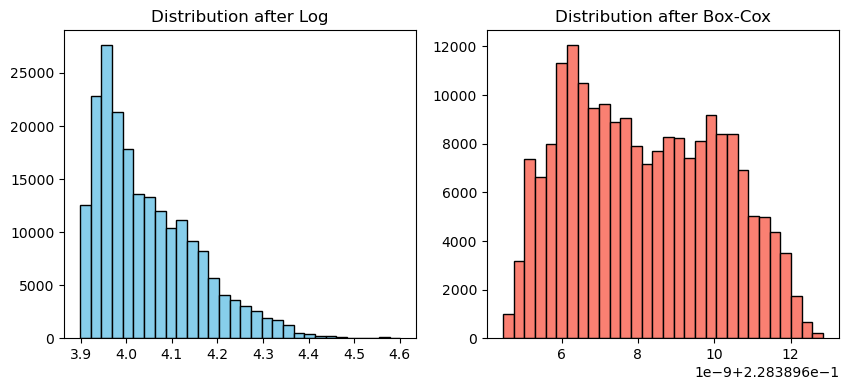

In [9]:
# Box-Cox transformation of surface hydrology values (if skewness after log transformation above 1.0)
# Data preparation Values need to be > 0

data_to_transform = df_valid["hydro_1km_mean"].copy()

if (data_to_transform <= 0).any():
    data_to_transform = data_to_transform + 0.00001

# Box-Cox transformation
df_valid["hydro_boxcox"], best_lambda = stats.boxcox(data_to_transform)

# Calculation of skewness
boxcox_skew = skew(df_valid["hydro_boxcox"])

print("="*50)
print(f"Optimal Lambda for Box-Cox: {best_lambda:.4f}")
print(f"Skewness after Box-Cox:        {boxcox_skew:.2f}")
print(f"Comparison to (Log):          {log_skew:.2f}")
print("="*50)

In [10]:
from scipy.stats import shapiro

# Shapiro-Wilk Test
sw_stat, sw_p = shapiro(df_valid["hydro_boxcox"])
print(f"Shapiro-Wilk Test: Statistics={sw_stat:.3f}, p-value={sw_p:.3f}")

Shapiro-Wilk Test: Statistics=0.965, p-value=0.000


C:\Users\Marco Karrer\.conda\envs\pystac_example\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 205273.
  res = hypotest_fun_out(*samples, **kwds)


In [107]:
# Global Bivariate Moran's analysis with KNN = 12
from esda.moran import Moran_BV

# trimming: possible if less time available for analysis (change if needed: ::5, ::20 for faster Speed)
df_stat = df_valid.iloc[::1].copy() 

# Spatial Weights Matrix (k-nearest neighbors)
coords = np.array([(geom.x, geom.y) for geom in df_stat.geometry]) #Coordinates for each point of the chosen sample are distrected
knn = libpysal.weights.KNN.from_array(coords, k=12)  #Matrix is genrated, in this case with 12 Neighbors
knn.transform = 'R'  #Means that each row has the same wigth on the output (1/12)

# definition of variables (x: target, y: neighbour)
# choose between raw, log or box-cox data
x = df_stat['ice_1km_mean'].values
#x = df_valid["ice_log_capped"]
y = df_stat['hydro_boxcox'].values
#y = df_valid["hydro_log_capped"].values

# Global bivariat Moran's test
moran_bv = Moran_BV(x, y, knn)
print("Global Bivariate Moran's Test:", round(moran_bv.I, 3))
print("p-Value (permutation test):", round(moran_bv.p_sim, 4))
z_score = (moran_bv.I - moran_bv.EI_sim) / np.sqrt(moran_bv.VI_sim)
print("Z-Score:", round(z_score, 3))

C:\Users\Marco Karrer\.conda\envs\pystac_example\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 34 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


Global Bivariate Moran's Test: 0.124
p-Value (permutation test): 0.001
Z-Score: 21.663


In [108]:
# Bivariate Moran's I analysis (uniform with KNN=12)

coords_stat = np.column_stack((df_stat.geometry.x, df_stat.geometry.y))

# Spatial Weights Matrix (k-nearest neighbors)
w = libpysal.weights.KNN.from_array(coords_stat, k=12)
w.transform = 'R'

# Adabt for which data to calculate (raw, log or box-cox)

moran_loc_bv = Moran_Local_BV(df_stat['ice_1km_mean'], df_stat['hydro_boxcox'], w)
#moran_loc_bv = Moran_Local_BV(df_stat['ice_1km_mean'], df_stat['hydro_log_capped'], w)
#moran_loc_bv = Moran_Local_BV(df_stat['ice_log_capped'], df_stat['hydro_log_capped'], w)
        
# FIX: .I durch den Mittelwert der lokalen Is ersetzen
print("-" * 30)
global_i_sim = np.mean(moran_loc_bv.Is)
print(f"Mean local Moran's I = {global_i_sim:.4f}")
print("-" * 30)
        
# results
df_stat['LISA_I'] = moran_loc_bv.Is      # local index
df_stat['LISA_p'] = moran_loc_bv.p_sim   # P-value 
df_stat['LISA_q'] = moran_loc_bv.q       # cluster (1:HH, 2:LH, 3:LL, 4:HL)

------------------------------
Mean local Moran's I = 0.1238
------------------------------


In [109]:
# Cluster statistics
# Significance value and number of points
alpha = 0.05
total_points = len(df_stat)
    
# Significance filter (p < 0.05)
significant_mask = df_stat['LISA_p'] < alpha
num_significant = significant_mask.sum()
pct_significant = (num_significant / total_points) * 100

# Mapping of Clusters and numbers
# PySAL Clusters: 1:HH, 2:LH, 3:LL, 4:HL
labels = {1: 'High-High (HH)', 2: 'Low-High (LH)', 3: 'Low-Low (LL)', 4: 'High-Low (HL)'}
    
print("\n" + "="*40)
print(f"LISA Cluster statistic (p < {alpha})")
print("="*40)
print(f"Total Points:      {total_points}")
print(f"Significant Points:  {num_significant} ({pct_significant:.2f}%)")
print("-" * 40)

# Number of each Cluster (only significant)
for q_val, label in labels.items():
    count = df_stat[significant_mask & (df_stat['LISA_q'] == q_val)].shape[0]
    pct_of_sig = (count / num_significant * 100) if num_significant > 0 else 0
    pct_of_total = (count / total_points * 100)
        
    print(f"{label:<15}: {count:>6} Points ({pct_of_total:>5.2f}% of Total)")

# Not significante Points
not_sig_count = total_points - num_significant
print(f"{'Not Significant':<15}: {not_sig_count:>6} Points ({not_sig_count/total_points*100:>5.2f}%)")
print("="*40)


LISA Cluster statistic (p < 0.05)
Total Points:      32293
Significant Points:  23047 (71.37%)
----------------------------------------
High-High (HH) :   4936 Points (15.29% of Total)
Low-High (LH)  :   5025 Points (15.56% of Total)
Low-Low (LL)   :   7285 Points (22.56% of Total)
High-Low (HL)  :   5801 Points (17.96% of Total)
Not Significant:   9246 Points (28.63%)


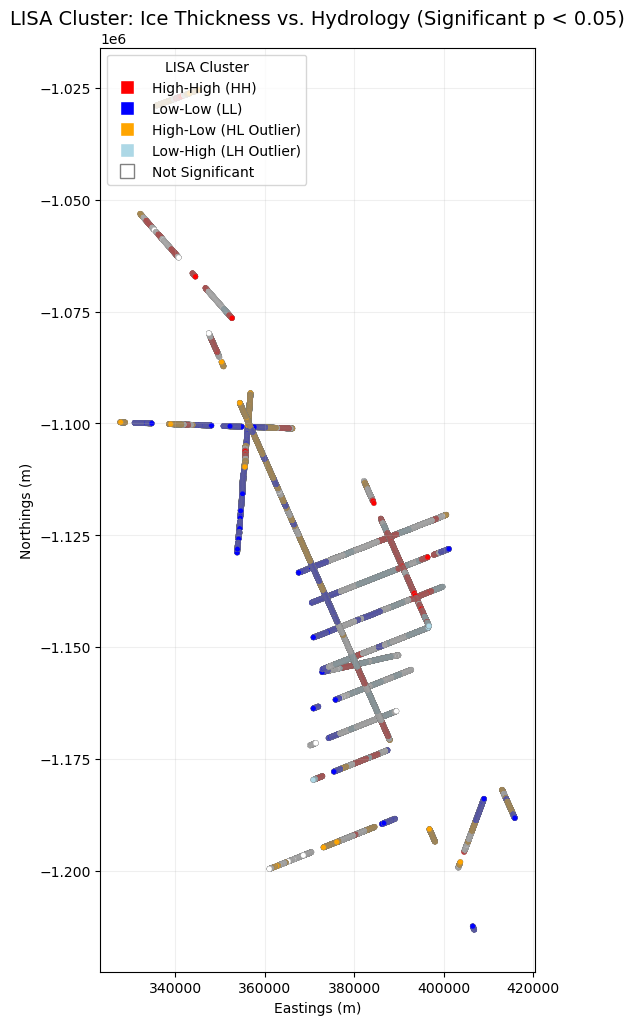

In [110]:
import matplotlib.pyplot as plt
import os

# Colour association
df_stat['Cluster_Label'] = 'Not Significant'
df_stat['Color'] = 'white'

# Significante Clusters (p < 0.05)
sig = df_stat['LISA_p'] < 0.05

df_stat.loc[sig & (df_stat['LISA_q'] == 1), ['Cluster_Label', 'Color']] = ['High-High (Hotspot)', 'red']
df_stat.loc[sig & (df_stat['LISA_q'] == 3), ['Cluster_Label', 'Color']] = ['Low-Low (Coldspot)', 'blue']
df_stat.loc[sig & (df_stat['LISA_q'] == 2), ['Cluster_Label', 'Color']] = ['Low-High (Outlier)', 'lightblue']
df_stat.loc[sig & (df_stat['LISA_q'] == 4), ['Cluster_Label', 'Color']] = ['High-Low (Outlier)', 'orange']

# Plotting
fig, ax = plt.subplots(figsize=(10, 12))
df_stat.plot(ax=ax, color=df_stat['Color'], edgecolor='grey', linewidth=0.2, markersize=15)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='s', color='w', label='High-High (HH)', markerfacecolor='red', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Low-Low (LL)', markerfacecolor='blue', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='High-Low (HL Outlier)', markerfacecolor='orange', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Low-High (LH Outlier)', markerfacecolor='lightblue', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Not Significant', markerfacecolor='white', markeredgecolor='grey', markersize=10)
]
ax.legend(handles=legend_elements, loc='upper left', title="LISA Cluster")

plt.title("LISA Cluster: Ice Thickness vs. Hydrology (Significant p < 0.05)", fontsize=14)
plt.xlabel("Eastings (m)")
plt.ylabel("Northings (m)")
plt.grid(alpha=0.2)

# Export as Geopackage
#output_path = "C:/Masterarbeit/Daten Masterarbeit/Outputs/Moran_Approach2/Icethickness_ClusterMap_NE_1.0kmR.gpkg"
#os.makedirs(os.path.dirname(output_path), exist_ok=True)
#df_stat.to_file(output_path, driver="GPKG")
plt.show()